In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
data = pd.read_csv('../data/Cleaned_Data.csv')
data.head()

,Area,Payment,Posted_by,Ownership,Status,Bedrooms,Bathrooms,Location,Pool,Electricity_Meter,Water_Meter,Natural_Gas,PrivateGarden,Landline,Covered_Parking,Security,Balcony,price
0,176.0,Cash,4 C,Resale,Ready,3.0,3.0,"Fifth Square Compound, 5th Settlement",0,1,1,1,0,1,1,1,0,10000000.0
1,125.0,Installment,Egypt Best Properties (EBP,Resale,Ready,2.0,2.0,"Mivida Compound, 5th Settlement",1,1,1,0,0,0,1,1,0,16800000.0
2,190.0,Cash,Egy Property,Resale,Ready,3.0,3.0,"Mivida Compound, 5th Settlement",1,1,1,1,1,1,1,1,1,18500000.0
3,115.0,Installment,Property Hills One 1,Primary,Ready,2.0,2.0,"Fifth Square Compound, 5th Settlement",0,1,1,1,0,1,1,1,0,14300000.0
4,165.0,Cash,Egypt Best Properties (EBP,Primary,Ready,3.0,3.0,"Mountain View iCity Compound, 5th Settlement",1,1,1,1,1,1,1,1,0,6150000.0


Descriptive statistics is important to to gain some intuition about our data so that we can evaluate the prediction of our model

In [5]:
data.describe()

,Area,Bedrooms,Bathrooms,Pool,Electricity_Meter,Water_Meter,Natural_Gas,PrivateGarden,Landline,Covered_Parking,Security,Balcony,price
count,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.000000,4157.0,4157.000000,4.157000e+03
mean,161.713736,2.727448,2.489295,0.300938,0.631706,0.594660,0.569401,0.414241,0.459707,0.601155,1.0,0.388742,9.222159e+06
std,33.431496,0.576279,0.630240,0.458721,0.482400,0.491017,0.495220,0.492650,0.498434,0.489720,0.0,0.487523,3.963448e+06
min,71.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,1.700000e+06
25%,140.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,6.200000e+06
50%,160.000000,3.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.0,0.000000,8.600000e+06
75%,180.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.180000e+07
max,255.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,2.121457e+07


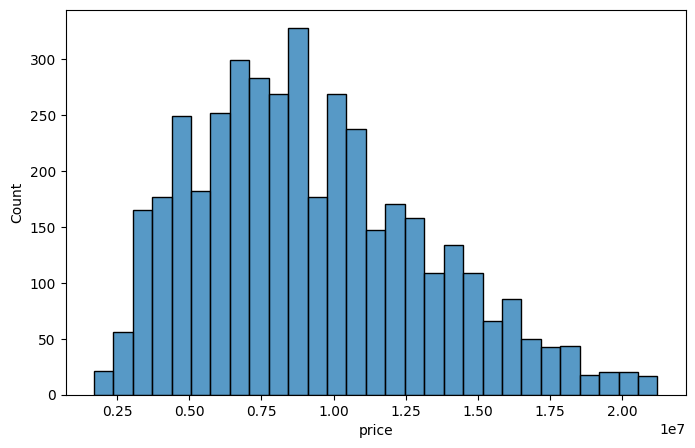

In [6]:
fig = plt.figure(figsize=(8,5))
sns.histplot(data=data,x='price')
plt.show()

Observations from the price distribution
* The data starts around 2,000,000 EGP and extends to 21,000,000 EGP. 
* The highest concentration of data points occurs in the 8,000,000 EGP to 9,000,000 EGP range, where the count exceeds 300 instances. 
* The distribution is right sckewed, This indicates that while most items are priced between 5,000,000 EGP and 10,000,000 EGP, there is a significant number of much more expensive outliers reaching up to 20,000,000 EGP and beyond.

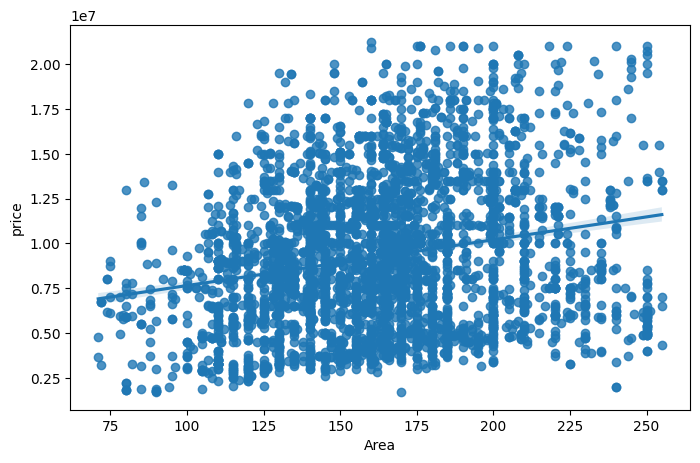

In [7]:
fig = plt.figure(figsize=(8,5))
sns.regplot(data=data,x='Area',y='price')
plt.show()

The regression line slopes upward from left to right, indicating a positive correlation. However, While there is an upward trend, the points do not cluster tightly around the line. This suggests that Area is only one factor affecting price, other variables like location, status, or luxury features likely play a significant role in determining the final cost.

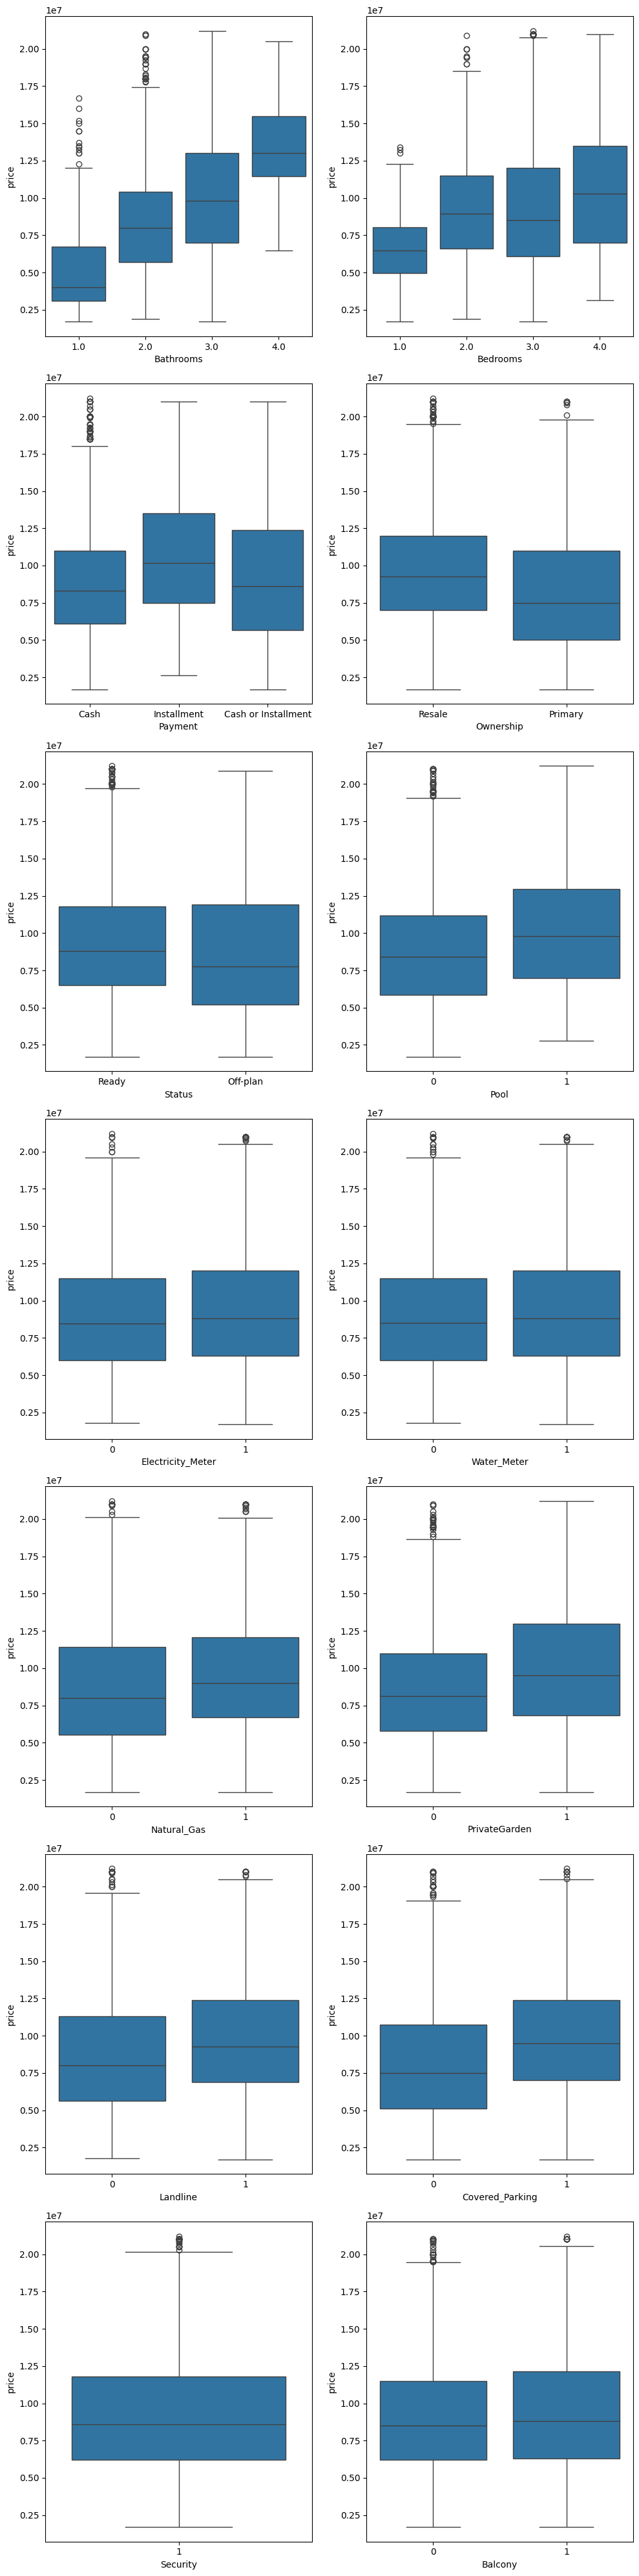

In [8]:
fig, axes = plt.subplots(7,2,figsize=(10,40))
sns.boxplot(data=data,x='Bathrooms',y='price',ax=axes[0,0])
sns.boxplot(data=data,x='Bedrooms',y='price',ax=axes[0,1])
sns.boxplot(x=data['Payment'],y=data['price'],ax=axes[1,0])
sns.boxplot(x=data['Ownership'],y=data['price'],ax=axes[1,1])
sns.boxplot(x=data['Status'],y=data['price'],ax=axes[2,0])
sns.boxplot(x=data['Pool'],y=data['price'],ax=axes[2,1])
sns.boxplot(x=data['Electricity_Meter'],y=data['price'],ax=axes[3,0])
sns.boxplot(x=data['Water_Meter'],y=data['price'],ax=axes[3,1])
sns.boxplot(x=data['Natural_Gas'],y=data['price'],ax=axes[4,0])
sns.boxplot(x=data['PrivateGarden'],y=data['price'],ax=axes[4,1])
sns.boxplot(x=data['Landline'],y=data['price'],ax=axes[5,0])
sns.boxplot(x=data['Covered_Parking'],y=data['price'],ax=axes[5,1])
sns.boxplot(x=data['Security'],y=data['price'],ax=axes[6,0])
sns.boxplot(x=data['Balcony'],y=data['price'],ax=axes[6,1])

plt.tight_layout()
plt.show()

1. Bathrooms shows the strongest positive correlation with price. As the number of bathrooms increases from 1 to 4, both the median price and the interquartile range IQR shift significantly upward.
2. Bedrooms also shows a strong correlation with price but less than bathrooms, because having Bedrooms are expected, not as premium as having more luxury bathrooms.
2. Ownership: Resale properties generally command a higher median price than Primary, because resale properties are usually in prime, ready, established locations , they are fully finished and ready to live
   
3. Payment Type: Properties allowing Installment payments have a higher median price compared to "Cash" only. This suggests that higher-value properties are more likely to offer financing plans to attract buyers.
   
4. Status: There is a slight premium for Ready properties over Off-plan, likely reflecting the value of immediate occupancy and reduced risk.
   
5. Amenities and Utilities :
* Pool and Private Garden show a noticeable increase in median price and upper-quartile values.
* Features like Natural Gas, Landline, and Covered Parking also correlate with higher median prices, though the overlap in price ranges between the two groups is larger so this means they have only moderate impact on the price.
* Features like Electricity Meter, Water Meter, and Balcony show very similar median prices regardless of the presence of the feature, suggesting these are standard or expected features that don't significantly drive a price premium.

6. Security: all properties in the set have security.


C:\Users\hamza\AppData\Local\Temp\ipykernel_15236\4089311134.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


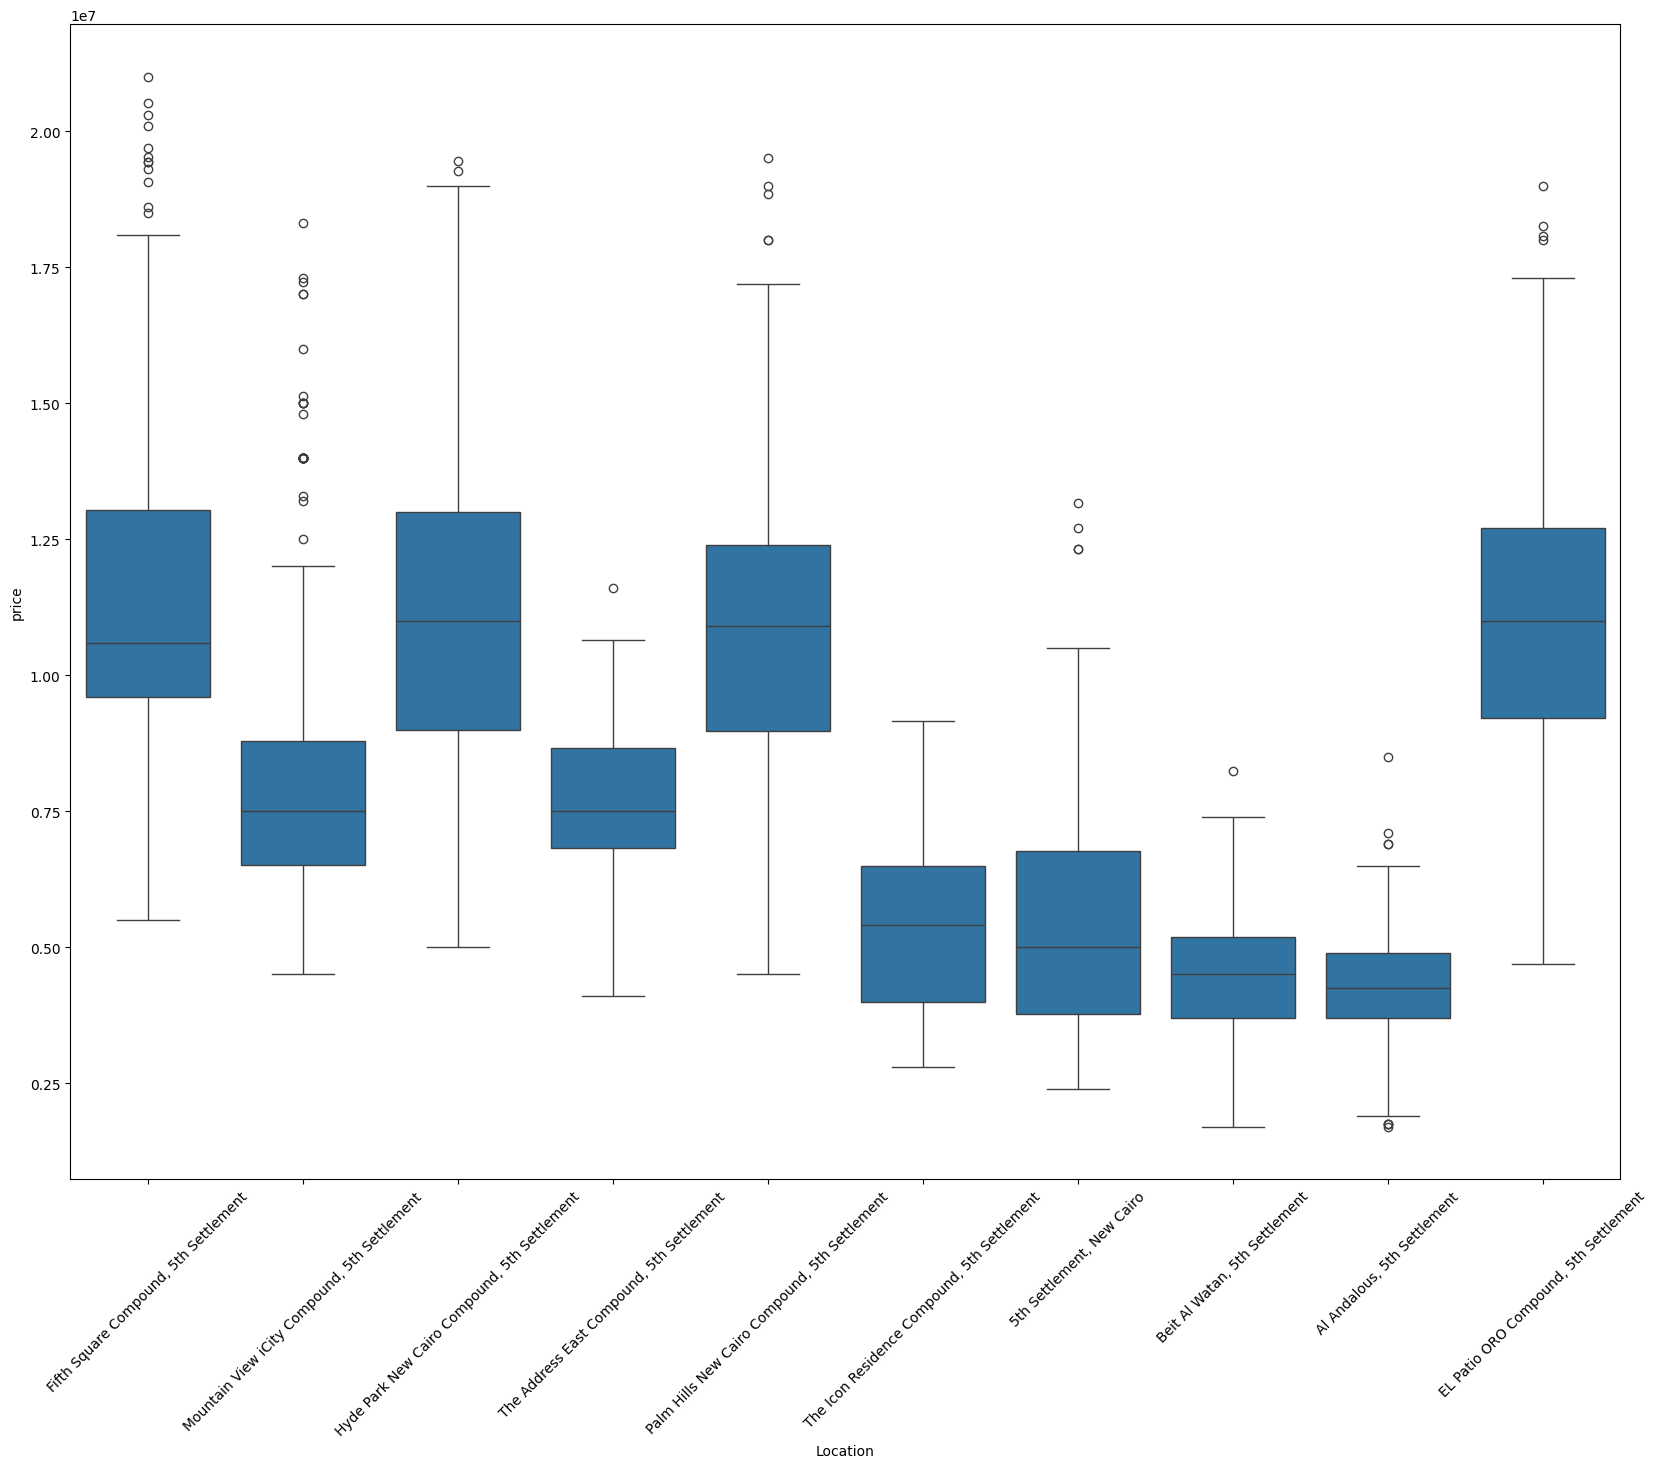

In [28]:
# Drawing the most common 10 locations

top_10 = data['Location'].value_counts().nlargest(10).index
filtered_data = data[data['Location'].isin(top10)]

fig = plt.figure(figsize=(20,15))
ax = sns.boxplot(x=filtered_data['Location'], y=filtered_data['price'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

We can see that median and IQR varies clearly from compound to another, this indicates that the location has strong effect on the price.